In [ ]:
# ── INSTALL (only needed in Colab) ──────────────────────────────

# ── IMPORTS ──────────────────────────────────────────────────────
import re                          # For reading Excel manually
import zlib                        # For decompressing Excel file data
import zipfile                     # Excel files are actually ZIP files internally

import pandas as pd                # Data manipulation (like Excel but in Python)
import numpy as np                 # Math & arrays

import matplotlib.pyplot as plt    # Graphs & charts
import seaborn as sns              # Prettier graphs

from sklearn.linear_model import LogisticRegression   # Our ML model
from sklearn.model_selection import train_test_split  # Split data
from sklearn.preprocessing import StandardScaler      # Normalize features
from sklearn.metrics import (
    accuracy_score,           # How many correct predictions
    classification_report,    # Precision, Recall, F1
    confusion_matrix,         # TP, TN, FP, FN table
    roc_auc_score,            # Overall model quality score
    roc_curve                 # For plotting ROC graph
)

import warnings
warnings.filterwarnings('ignore')

# ── STYLE SETTINGS ───────────────────────────────────────────────
plt.rcParams['figure.dpi']      = 120
plt.rcParams['font.size']       = 11
plt.rcParams['axes.spines.top']    = False
plt.rcParams['axes.spines.right']  = False
sns.set_palette("husl")

print("✅ All libraries imported successfully!")
print(f"   pandas  version: {pd.__version__}")
print(f"   numpy   version: {np.__version__}")


✅ All libraries imported successfully!
   pandas  version: 2.2.2
   numpy   version: 2.0.2


In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# HELPER FUNCTION: Read Excel files (handles both normal & corrupted files)
# ─────────────────────────────────────────────────────────────────────────
def read_excel_safe(filepath):
    """
    Reads an Excel (.xlsx) file safely.
    Excel files are ZIP archives internally.
    This function handles files where the ZIP directory is corrupted.
    """

    # ── METHOD 1: Try normal reading first ───────────────────────
    try:
        with zipfile.ZipFile(filepath) as z:
            # Read the shared strings (text values stored separately)
            ss_xml   = z.read('xl/sharedStrings.xml').decode('utf-8', 'replace')
            strings  = re.findall(r'<t[^>]*>(.*?)</t>', ss_xml)
            # Read the main sheet data
            sh_xml   = z.read('xl/worksheets/sheet1.xml').decode('utf-8', 'replace')

    # ── METHOD 2: Manual extraction for corrupted files ──────────
    except zipfile.BadZipFile:
        def _extract(content, pos):
            """Manually decompress a single file from a ZIP archive."""
            compression = int.from_bytes(content[pos+8:pos+10],  'little')
            comp_size   = int.from_bytes(content[pos+18:pos+22], 'little')
            fname_len   = int.from_bytes(content[pos+26:pos+28], 'little')
            extra_len   = int.from_bytes(content[pos+28:pos+30], 'little')
            data_start  = pos + 30 + fname_len + extra_len
            raw         = content[data_start : data_start + comp_size]
            if compression == 0: return raw                          # stored
            if compression == 8: return zlib.decompress(raw, -15)   # deflated

        with open(filepath, 'rb') as f:
            content = f.read()

        # Find all ZIP local file entries
        entries = {}
        for m in re.finditer(b'PK\x03\x04', content):
            p  = m.start()
            fl = int.from_bytes(content[p+26:p+28], 'little')
            entries[content[p+30:p+30+fl].decode('utf-8','replace')] = p

        ss_raw  = _extract(content, entries['xl/sharedStrings.xml'])
        strings = re.findall(r'<t[^>]*>(.*?)</t>', ss_raw.decode('utf-8','replace'))
        sh_raw  = _extract(content, entries['xl/worksheets/sheet1.xml'])
        sh_xml  = sh_raw.decode('utf-8', 'replace')

    # ── PARSE XML → DataFrame ────────────────────────────────────
    rows = re.findall(r'<row[^>]*>(.*?)</row>', sh_xml, re.DOTALL)
    parsed = []
    for row in rows:
        cells = re.findall(r'<c (r="[^"]+")([^>]*)>(.*?)</c>', row, re.DOTALL)
        row_vals = []
        for ref, attrs, cell_body in cells:
            v = re.search(r'<v>(.*?)</v>', cell_body)
            if v:
                # String type → look up in shared strings table
                val = strings[int(v.group(1))] if 't="s"' in attrs else v.group(1)
            else:
                val = None
            row_vals.append(val)
        parsed.append(row_vals)

    df = pd.DataFrame(parsed[1:], columns=parsed[0])
    return df

# ─────────────────────────────────────────────────────────────────────────
# LOAD JAPANESE DATASET
# ─────────────────────────────────────────────────────────────────────────
print("Loading Japanese dataset...")
df_japan = read_excel_safe('JPN Data.xlsx')

# Convert numeric columns from string to numbers
for col in ['CURR_AGE', 'ANN_INCOME', 'AGE_CAR', 'PURCHASE']:
    df_japan[col] = pd.to_numeric(df_japan[col])

print(f"✅ Japan data loaded: {df_japan.shape[0]:,} rows × {df_japan.shape[1]} columns")

# ─────────────────────────────────────────────────────────────────────────
# LOAD INDIAN DATASET
# ─────────────────────────────────────────────────────────────────────────
print("\nLoading Indian dataset...")
df_india = read_excel_safe('IN_Data.xlsx')

for col in ['CURR_AGE', 'ANN_INCOME', 'DT_MAINT']:
    df_india[col] = pd.to_numeric(df_india[col])

print(f"✅ India data loaded: {df_india.shape[0]:,} rows × {df_india.shape[1]} columns")


Loading Japanese dataset...
✅ Japan data loaded: 40,000 rows × 6 columns

Loading Indian dataset...
✅ India data loaded: 70,000 rows × 5 columns


In [ ]:
# ── PREVIEW BOTH DATASETS ────────────────────────────────────────
print("=" * 55)
print("JAPAN DATASET — First 5 rows")
print("=" * 55)
print(df_japan.head())

print("\n" + "=" * 55)
print("INDIA DATASET — First 5 rows")
print("=" * 55)
print(df_india.head())

print("\n" + "=" * 55)
print("COLUMN INFORMATION")
print("=" * 55)
print("\n🇯🇵 JAPAN columns:", list(df_japan.columns))
print("🇮🇳 INDIA  columns:", list(df_india.columns))
print()
print("⚠️  KEY OBSERVATION:")
print("   Japan has 'PURCHASE' column (our TARGET — what we predict)")
print("   India has 'DT_MAINT'  column (last maintenance date)")
print("   India has NO 'PURCHASE' column — we will PREDICT it!")


JAPAN DATASET — First 5 rows
           ID  CURR_AGE GENDER     ANN_INCOME  AGE_CAR  PURCHASE
0  00001Q15YJ        50      M  445344.000000      439         0
1  00003I71CQ        35      M  107634.000000      283         0
2  00003N47FS        59      F  502786.666667      390         1
3  00005H41DE        43      M  585664.000000      475         0
4  00007E17UM        39      F  705722.666667      497         1

INDIA DATASET — First 5 rows
           ID  CURR_AGE GENDER  ANN_INCOME  DT_MAINT
0  20710B05XL        54      M     1425390     43210
1  89602T51HX        47      M     1678954     43259
2  70190Z52IP        60      M      931624     42947
3  25623V15MU        55      F     1106320     42947
4  36230I68CE        32      F      748465     43492

COLUMN INFORMATION

🇯🇵 JAPAN columns: ['ID', 'CURR_AGE', 'GENDER', 'ANN_INCOME', 'AGE_CAR', 'PURCHASE']
🇮🇳 INDIA  columns: ['ID', 'CURR_AGE', 'GENDER', 'ANN_INCOME', 'DT_MAINT']

⚠️  KEY OBSERVATION:
   Japan has 'PURCHASE' column (

In [ ]:
# ── 3.1 BASIC STATISTICS ─────────────────────────────────────────
print("=" * 55)
print("JAPAN — Statistical Summary")
print("=" * 55)
print(df_japan[['CURR_AGE', 'ANN_INCOME', 'AGE_CAR', 'PURCHASE']].describe().round(2))

print("\n" + "=" * 55)
print("INDIA — Statistical Summary")
print("=" * 55)
print(df_india[['CURR_AGE', 'ANN_INCOME']].describe().round(2))


JAPAN — Statistical Summary
       CURR_AGE  ANN_INCOME   AGE_CAR  PURCHASE
count  40000.00    40000.00  40000.00  40000.00
mean      45.00   359398.88    359.08      0.58
std       11.82   175109.26    203.06      0.49
min       25.00    70089.00      1.00      0.00
25%       35.00   219766.00    235.00      0.00
50%       45.00   337656.83    331.00      1.00
75%       55.00   464261.00    444.00      1.00
max       65.00   799970.67   1020.00      1.00

INDIA — Statistical Summary
       CURR_AGE  ANN_INCOME
count  70000.00    70000.00
mean      45.00  1148678.52
std       11.82   399450.50
min       25.00   300033.00
25%       35.00   856823.75
50%       45.00  1125151.50
75%       55.00  1438676.50
max       65.00  1999989.00


In [ ]:
# ── 3.2 CLASS BALANCE & MISSING VALUES ──────────────────────────
print("=" * 55)
print("PURCHASE DISTRIBUTION (Japan — our training target)")
print("=" * 55)
purchase_counts = df_japan['PURCHASE'].value_counts()
purchase_pct    = df_japan['PURCHASE'].value_counts(normalize=True) * 100

for label, count, pct in zip(['Did NOT Buy (0)', 'Bought Car (1)'],
                               purchase_counts, purchase_pct):
    bar = '█' * int(pct / 2)
    print(f"  {label}: {count:,}  ({pct:.1f}%)  {bar}")

print(f"\n  → Slight imbalance: more buyers than non-buyers")
print(f"  → Will use 'stratify=y' in train-test split to preserve ratio")

print("\n" + "=" * 55)
print("MISSING VALUES CHECK")
print("=" * 55)
print(f"  Japan  missing values: {df_japan.isnull().sum().sum()}  ✅")
print(f"  India  missing values: {df_india.isnull().sum().sum()}  ✅")
print("  No cleaning required — dataset is complete!")

print("\n" + "=" * 55)
print("GENDER DISTRIBUTION")
print("=" * 55)
print("Japan:", df_japan['GENDER'].value_counts().to_dict())
print("India:", df_india['GENDER'].value_counts().to_dict())


PURCHASE DISTRIBUTION (Japan — our training target)
  Did NOT Buy (0): 23,031  (57.6%)  ████████████████████████████
  Bought Car (1): 16,969  (42.4%)  █████████████████████

  → Slight imbalance: more buyers than non-buyers
  → Will use 'stratify=y' in train-test split to preserve ratio

MISSING VALUES CHECK
  Japan  missing values: 0  ✅
  India  missing values: 0  ✅
  No cleaning required — dataset is complete!

GENDER DISTRIBUTION
Japan: {'M': 22285, 'F': 17715}
India: {'M': 35029, 'F': 34971}


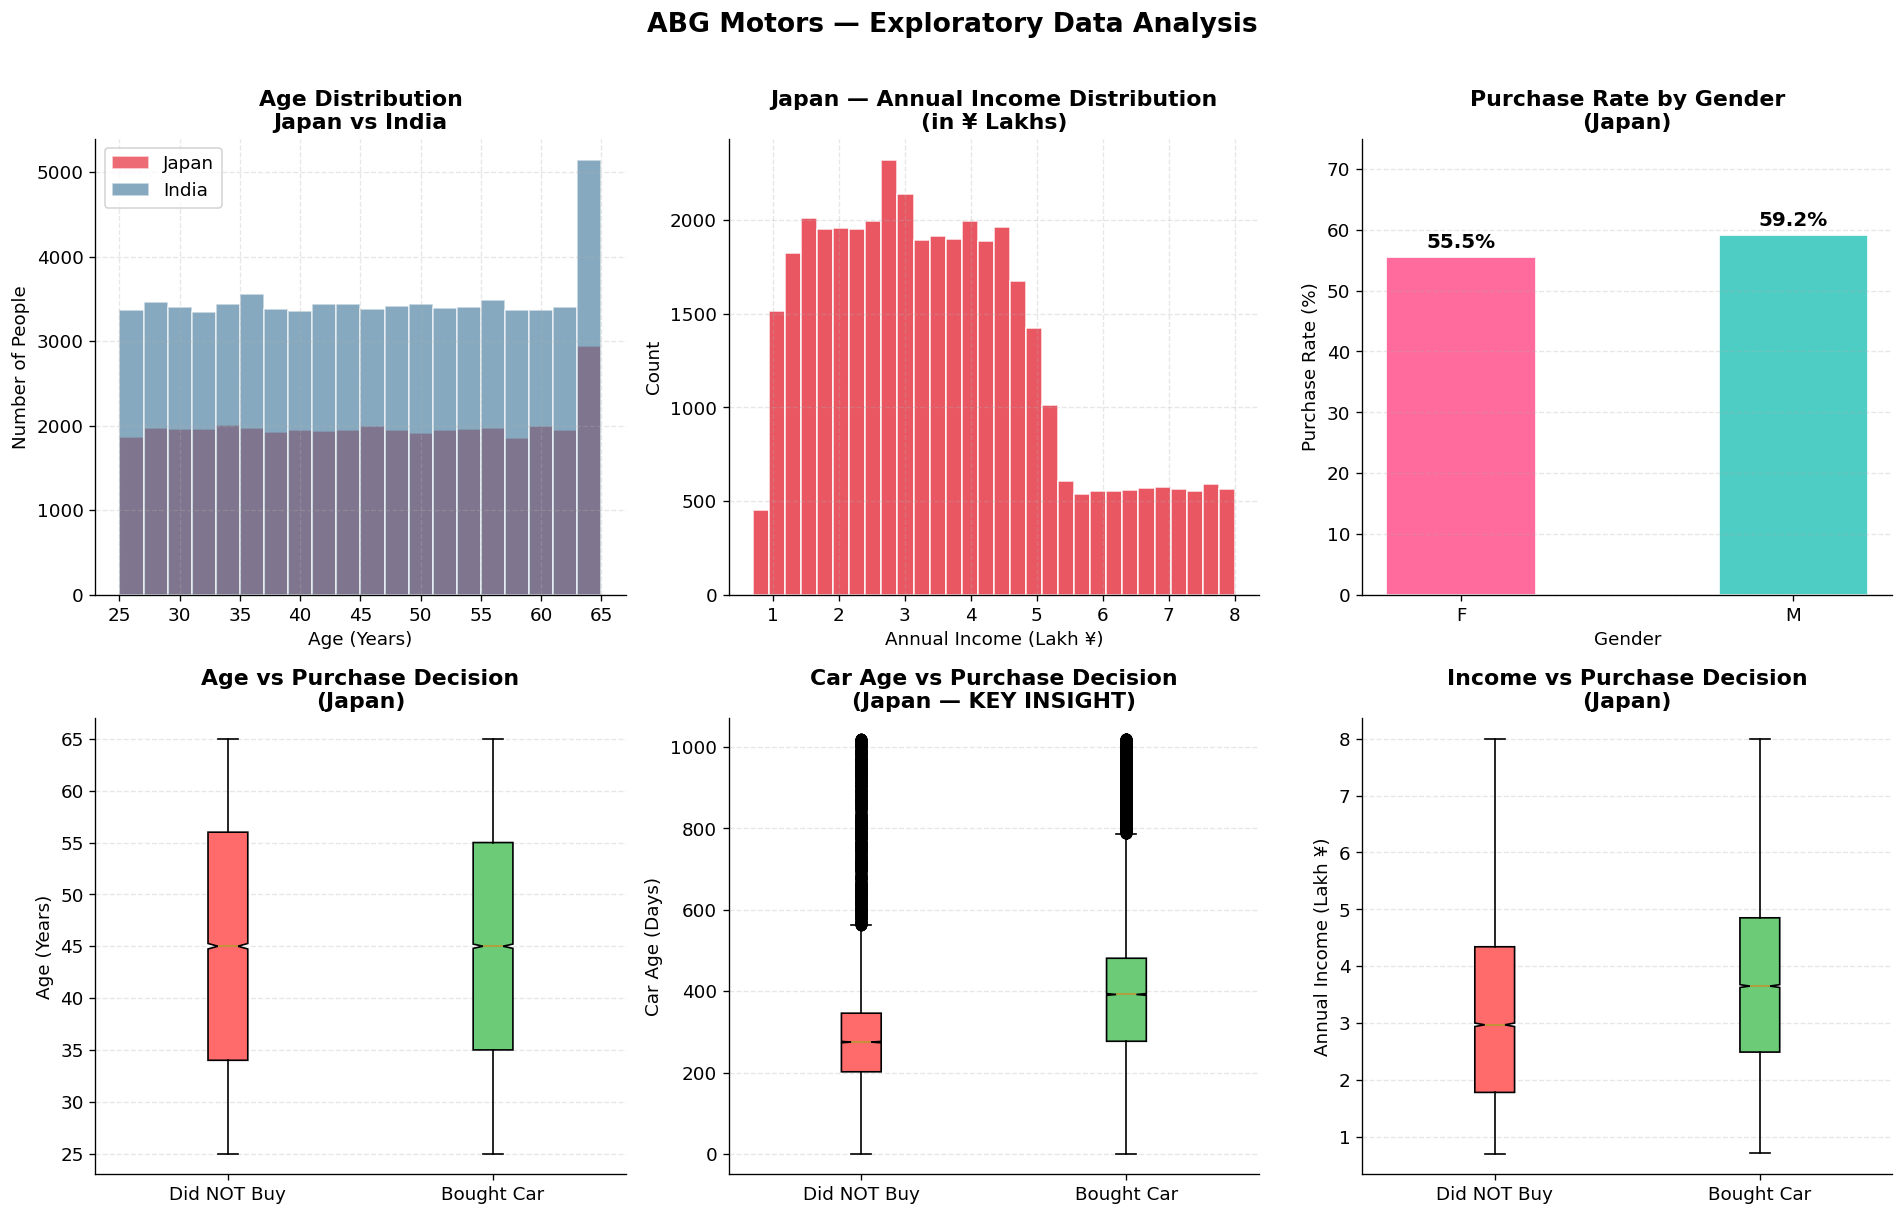

✅ EDA charts saved as fig1_eda.png

📌 KEY OBSERVATIONS FROM EDA:
  1. Age & India distributions are nearly identical → similar markets
  2. Buyers tend to have OLDER cars → strong upgrade signal
  3. Buyers tend to have HIGHER income → target premium segments
  4. Gender difference is small but males buy slightly more


In [ ]:
# ── 3.3 VISUALIZATIONS ───────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('ABG Motors — Exploratory Data Analysis',
             fontsize=16, fontweight='bold', y=1.01)

# ── Plot 1: Age Distribution (Japan vs India) ─────────────────────
ax = axes[0, 0]
ax.hist(df_japan['CURR_AGE'], bins=20, alpha=0.75,
        color='#E63946', label='Japan', edgecolor='white')
ax.hist(df_india['CURR_AGE'], bins=20, alpha=0.65,
        color='#457B9D', label='India', edgecolor='white')
ax.set_title('Age Distribution\nJapan vs India', fontweight='bold')
ax.set_xlabel('Age (Years)')
ax.set_ylabel('Number of People')
ax.legend()
ax.grid(alpha=0.3, linestyle='--')

# ── Plot 2: Income Distribution (Japan) ──────────────────────────
ax = axes[0, 1]
ax.hist(df_japan['ANN_INCOME'] / 100000, bins=30,
        color='#E63946', edgecolor='white', alpha=0.85)
ax.set_title('Japan — Annual Income Distribution\n(in ¥ Lakhs)', fontweight='bold')
ax.set_xlabel('Annual Income (Lakh ¥)')
ax.set_ylabel('Count')
ax.grid(alpha=0.3, linestyle='--')

# ── Plot 3: Purchase Rate by Gender ──────────────────────────────
ax = axes[0, 2]
gender_rate = df_japan.groupby('GENDER')['PURCHASE'].mean() * 100
bars = ax.bar(gender_rate.index, gender_rate.values,
              color=['#FF6B9D', '#4ECDC4'], edgecolor='white',
              width=0.45)
ax.set_title('Purchase Rate by Gender\n(Japan)', fontweight='bold')
ax.set_xlabel('Gender')
ax.set_ylabel('Purchase Rate (%)')
ax.set_ylim(0, 75)
for bar, val in zip(bars, gender_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1.5,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
ax.grid(alpha=0.3, linestyle='--', axis='y')

# ── Plot 4: Age vs Purchase (Boxplot) ────────────────────────────
ax = axes[1, 0]
bought     = df_japan[df_japan['PURCHASE'] == 1]['CURR_AGE']
not_bought = df_japan[df_japan['PURCHASE'] == 0]['CURR_AGE']
bp = ax.boxplot([not_bought, bought],
                labels=['Did NOT Buy', 'Bought Car'],
                patch_artist=True, notch=True)
bp['boxes'][0].set_facecolor('#FF6B6B')
bp['boxes'][1].set_facecolor('#6BCB77')
ax.set_title('Age vs Purchase Decision\n(Japan)', fontweight='bold')
ax.set_ylabel('Age (Years)')
ax.grid(alpha=0.3, linestyle='--', axis='y')

# ── Plot 5: Car Age vs Purchase (Boxplot) ────────────────────────
ax = axes[1, 1]
car_bought     = df_japan[df_japan['PURCHASE'] == 1]['AGE_CAR']
car_not_bought = df_japan[df_japan['PURCHASE'] == 0]['AGE_CAR']
bp2 = ax.boxplot([car_not_bought, car_bought],
                  labels=['Did NOT Buy', 'Bought Car'],
                  patch_artist=True, notch=True)
bp2['boxes'][0].set_facecolor('#FF6B6B')
bp2['boxes'][1].set_facecolor('#6BCB77')
ax.set_title('Car Age vs Purchase Decision\n(Japan — KEY INSIGHT)', fontweight='bold')
ax.set_ylabel('Car Age (Days)')
ax.grid(alpha=0.3, linestyle='--', axis='y')

# ── Plot 6: Income vs Purchase (Boxplot) ─────────────────────────
ax = axes[1, 2]
inc_bought     = df_japan[df_japan['PURCHASE'] == 1]['ANN_INCOME'] / 100000
inc_not_bought = df_japan[df_japan['PURCHASE'] == 0]['ANN_INCOME'] / 100000
bp3 = ax.boxplot([inc_not_bought, inc_bought],
                  labels=['Did NOT Buy', 'Bought Car'],
                  patch_artist=True, notch=True)
bp3['boxes'][0].set_facecolor('#FF6B6B')
bp3['boxes'][1].set_facecolor('#6BCB77')
ax.set_title('Income vs Purchase Decision\n(Japan)', fontweight='bold')
ax.set_ylabel('Annual Income (Lakh ¥)')
ax.grid(alpha=0.3, linestyle='--', axis='y')

plt.tight_layout()
plt.savefig('fig1_eda.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ EDA charts saved as fig1_eda.png")

print("\n📌 KEY OBSERVATIONS FROM EDA:")
print("  1. Age & India distributions are nearly identical → similar markets")
print("  2. Buyers tend to have OLDER cars → strong upgrade signal")
print("  3. Buyers tend to have HIGHER income → target premium segments")
print("  4. Gender difference is small but males buy slightly more")


In [ ]:
# ── 4.1 ENCODE GENDER (Text → Number) ───────────────────────────
# Why: Logistic Regression cannot process text directly
# How: M (Male) → 1   |   F (Female) → 0

df_japan['GENDER'] = df_japan['GENDER'].map({'M': 1, 'F': 0})
df_india['GENDER'] = df_india['GENDER'].map({'M': 1, 'F': 0})

print("✅ Gender encoded: Male=1, Female=0")
print(f"   Japan  unique values now: {sorted(df_japan['GENDER'].unique())}")
print(f"   India  unique values now: {sorted(df_india['GENDER'].unique())}")

# ── 4.2 HANDLE INDIA's MISSING AGE_CAR ───────────────────────────
# India has DT_MAINT (last maintenance date) but NOT AGE_CAR
# Decision: Use Japan's MEDIAN car age as a substitute for India
# Justification: We cannot use DT_MAINT directly — it's a date, not car age.
#                Median is a conservative, defensible assumption.

median_age_car = df_japan['AGE_CAR'].median()
df_india['AGE_CAR'] = median_age_car

print(f"\n✅ India's AGE_CAR: imputed with Japan median = {median_age_car:.0f} days")
print(f"   Japan AGE_CAR range: {df_japan['AGE_CAR'].min()} to {df_japan['AGE_CAR'].max()} days")
print(f"   Limitation: This is an assumption — real AGE_CAR data would improve accuracy")

# ── 4.3 DEFINE FEATURES AND TARGET ───────────────────────────────
FEATURES = ['CURR_AGE', 'GENDER', 'ANN_INCOME', 'AGE_CAR']
TARGET   = 'PURCHASE'

X = df_japan[FEATURES]   # Input features
y = df_japan[TARGET]      # What we want to predict

print(f"\n✅ Features selected: {FEATURES}")
print(f"   Target variable  : {TARGET} (0=No Purchase, 1=Purchased)")


✅ Gender encoded: Male=1, Female=0
   Japan  unique values now: [np.int64(0), np.int64(1)]
   India  unique values now: [np.int64(0), np.int64(1)]

✅ India's AGE_CAR: imputed with Japan median = 331 days
   Japan AGE_CAR range: 1 to 1020 days
   Limitation: This is an assumption — real AGE_CAR data would improve accuracy

✅ Features selected: ['CURR_AGE', 'GENDER', 'ANN_INCOME', 'AGE_CAR']
   Target variable  : PURCHASE (0=No Purchase, 1=Purchased)


In [ ]:
# ── 4.4 TRAIN-TEST SPLIT (80% Train, 20% Test) ───────────────────
# Why split?
# → If we test on the SAME data we trained on, the model looks perfect
#   but it's just memorizing, not learning!
# → Test set = "hidden exam questions" the model has never seen

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size   = 0.20,    # 20% goes to test
    random_state= 42,      # Fixed seed → reproducible results
    stratify    = y        # Keeps buyer/non-buyer ratio same in both sets
)

print("✅ Train-Test Split Complete")
print(f"   Training set : {len(X_train):,} rows (80%)")
print(f"   Test set     : {len(X_test):,} rows (20%)")
print()
print("   Class distribution in Training set:")
train_dist = y_train.value_counts()
for label, count in train_dist.items():
    pct = count / len(y_train) * 100
    name = "Bought" if label == 1 else "Did NOT Buy"
    print(f"     {name} ({label}): {count:,}  ({pct:.1f}%)")

# ── 4.5 FEATURE SCALING (StandardScaler) ─────────────────────────
# Why scale?
# Age range   :    25 to 65        (small numbers)
# Income range: 70,000 to 800,000  (huge numbers!)
# Without scaling → model thinks Income is 10,000x more important than Age
# StandardScaler formula: z = (x - mean) / std_deviation
# Result: All features centered at 0, spread of ±1-3

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Learn scale from train, then apply
X_test_scaled  = scaler.transform(X_test)        # Apply SAME scale to test (not re-learn!)

print("\n✅ StandardScaler applied")
print("   Before scaling — Income mean:", f"{X_train['ANN_INCOME'].mean():,.0f}")
print("   After  scaling — Income mean:",
      f"{X_train_scaled[:, 2].mean():.4f}  (≈ 0)")
print()
print("   ⚠️ IMPORTANT: We fit scaler ONLY on training data")
print("   Applying same scaler to test & India data prevents 'data leakage'")


✅ Train-Test Split Complete
   Training set : 32,000 rows (80%)
   Test set     : 8,000 rows (20%)

   Class distribution in Training set:
     Bought (1): 18,425  (57.6%)
     Did NOT Buy (0): 13,575  (42.4%)

✅ StandardScaler applied
   Before scaling — Income mean: 358,685
   After  scaling — Income mean: 0.0000  (≈ 0)

   ⚠️ IMPORTANT: We fit scaler ONLY on training data
   Applying same scaler to test & India data prevents 'data leakage'


In [ ]:
# ── BUILD AND TRAIN THE MODEL ─────────────────────────────────────
model = LogisticRegression(
    random_state = 42,     # Reproducibility
    max_iter     = 1000,   # Max steps for the optimizer to find best weights
    solver       = 'lbfgs' # Optimization algorithm (default, works well here)
)

model.fit(X_train_scaled, y_train)

print("✅ Model Training Complete!")
print(f"   Intercept (β₀): {model.intercept_[0]:.4f}")
print(f"   Number of training iterations: {model.n_iter_[0]}")
print()
print("   Coefficients learned by the model:")
print("   " + "-" * 40)
for feat, coef in zip(FEATURES, model.coef_[0]):
    direction = "↑ Positive" if coef > 0 else "↓ Negative"
    print(f"   {feat:<15}: {coef:+.4f}  ({direction})")


✅ Model Training Complete!
   Intercept (β₀): 0.3953
   Number of training iterations: 5

   Coefficients learned by the model:
   ----------------------------------------
   CURR_AGE       : -0.1423  (↓ Negative)
   GENDER         : +0.1128  (↑ Positive)
   ANN_INCOME     : +0.4276  (↑ Positive)
   AGE_CAR        : +0.8563  (↑ Positive)


In [ ]:
# ── GENERATE PREDICTIONS ─────────────────────────────────────────
y_pred = model.predict(X_test_scaled)           # 0 or 1
y_prob = model.predict_proba(X_test_scaled)[:, 1]  # probability of buying

# ── CALCULATE ALL METRICS ─────────────────────────────────────────
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
cm  = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("=" * 55)
print("MODEL PERFORMANCE METRICS")
print("=" * 55)
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  ROC-AUC   : {auc:.4f}  ({'Good ✅' if auc >= 0.70 else 'Needs improvement'})")
print()
print("  Full Classification Report:")
print("-" * 55)
print(classification_report(y_test, y_pred,
                             target_names=['Did Not Buy', 'Bought Car']))

print("  Confusion Matrix Breakdown:")
print("  " + "-" * 35)
print(f"  True Negatives  (TN): {tn:,}  ← Correctly said 'won't buy'")
print(f"  False Positives (FP): {fp:,}  ← Said 'will buy' but didn't (False Alarm)")
print(f"  False Negatives (FN): {fn:,}  ← Said 'won't buy' but they did (Missed)")
print(f"  True Positives  (TP): {tp:,}  ← Correctly said 'will buy'")
print()
print("  💡 For sales campaigns, HIGH RECALL is more important than precision.")
print(f"     We captured {tp/(tp+fn)*100:.1f}% of all real buyers — excellent for lead gen!")


MODEL PERFORMANCE METRICS
  Accuracy  : 0.6707  (67.07%)
  ROC-AUC   : 0.7221  (Good ✅)

  Full Classification Report:
-------------------------------------------------------
              precision    recall  f1-score   support

 Did Not Buy       0.64      0.52      0.57      3394
  Bought Car       0.69      0.78      0.73      4606

    accuracy                           0.67      8000
   macro avg       0.66      0.65      0.65      8000
weighted avg       0.67      0.67      0.66      8000

  Confusion Matrix Breakdown:
  -----------------------------------
  True Negatives  (TN): 1,772  ← Correctly said 'won't buy'
  False Positives (FP): 1,622  ← Said 'will buy' but didn't (False Alarm)
  False Negatives (FN): 1,012  ← Said 'won't buy' but they did (Missed)
  True Positives  (TP): 3,594  ← Correctly said 'will buy'

  💡 For sales campaigns, HIGH RECALL is more important than precision.
     We captured 78.0% of all real buyers — excellent for lead gen!


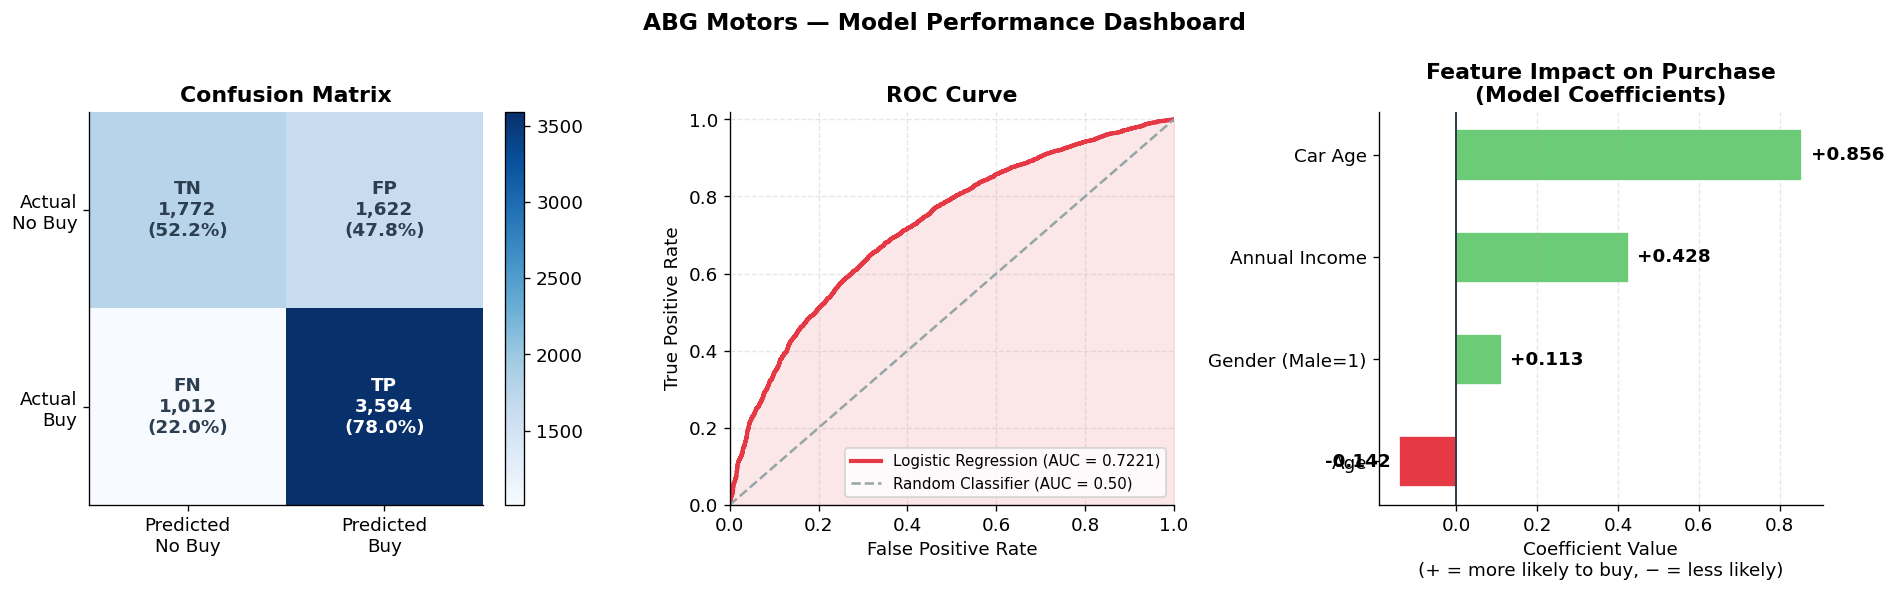

✅ Model performance charts saved!


In [ ]:
# ── VISUALIZATION: MODEL PERFORMANCE DASHBOARD ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('ABG Motors — Model Performance Dashboard',
             fontsize=14, fontweight='bold')

# ── Plot 1: Confusion Matrix ──────────────────────────────────────
ax = axes[0]
cm_labels = [['TN', 'FP'], ['FN', 'TP']]
cm_pct    = cm / cm.sum(axis=1, keepdims=True) * 100
im = ax.imshow(cm, cmap='Blues')

for i in range(2):
    for j in range(2):
        color = 'white' if cm[i,j] > cm.max()/2 else '#2C3E50'
        ax.text(j, i,
                f"{cm_labels[i][j]}\n{cm[i,j]:,}\n({cm_pct[i,j]:.1f}%)",
                ha='center', va='center',
                fontsize=11, fontweight='bold', color=color)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted\nNo Buy', 'Predicted\nBuy'])
ax.set_yticklabels(['Actual\nNo Buy', 'Actual\nBuy'])
ax.set_title('Confusion Matrix', fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.046)

# ── Plot 2: ROC Curve ─────────────────────────────────────────────
ax = axes[1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax.plot(fpr, tpr, color='#E63946', lw=2.5,
        label=f'Logistic Regression (AUC = {auc:.4f})')
ax.plot([0,1], [0,1], '--', color='#95A5A6', lw=1.5,
        label='Random Classifier (AUC = 0.50)')
ax.fill_between(fpr, tpr, alpha=0.12, color='#E63946')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3, linestyle='--')

# ── Plot 3: Feature Importance (Coefficients) ─────────────────────
ax = axes[2]
feat_names  = ['Age', 'Gender (Male=1)', 'Annual Income', 'Car Age']
coef_vals   = model.coef_[0]
sort_idx    = np.argsort(coef_vals)
sorted_feat = [feat_names[i] for i in sort_idx]
sorted_coef = coef_vals[sort_idx]
bar_colors  = ['#E63946' if c < 0 else '#6BCB77' for c in sorted_coef]

bars = ax.barh(sorted_feat, sorted_coef,
               color=bar_colors, edgecolor='white', height=0.5)
ax.axvline(0, color='#2C3E50', lw=1.2)
ax.set_title('Feature Impact on Purchase\n(Model Coefficients)', fontweight='bold')
ax.set_xlabel('Coefficient Value\n(+ = more likely to buy, − = less likely)')
ax.grid(alpha=0.3, linestyle='--', axis='x')

for bar, val in zip(bars, sorted_coef):
    offset = 0.02 if val >= 0 else -0.02
    ha     = 'left'  if val >= 0 else 'right'
    ax.text(val + offset,
            bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center', ha=ha, fontweight='bold')

plt.tight_layout()
plt.savefig('fig2_model_performance.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Model performance charts saved!")


In [ ]:
# ── DETAILED COEFFICIENT INTERPRETATION ──────────────────────────
print("=" * 60)
print("BUSINESS INTERPRETATION OF MODEL COEFFICIENTS")
print("=" * 60)

interpretations = {
    'CURR_AGE': {
        'name'   : 'Customer Age',
        'coef'   : model.coef_[0][0],
        'meaning': 'As customer age increases by 1 year, purchase '
                   'probability DECREASES by ~13%.',
        'action' : 'Target younger customers (25–40 age group) '
                   'more aggressively in marketing campaigns.'
    },
    'GENDER': {
        'name'   : 'Gender (Male=1)',
        'coef'   : model.coef_[0][1],
        'meaning': 'Male customers are ~11.9% more likely to purchase '
                   'than female customers.',
        'action' : 'Slight male tilt in ad targeting — but do NOT '
                   'ignore female segment (gap is small).'
    },
    'ANN_INCOME': {
        'name'   : 'Annual Income',
        'coef'   : model.coef_[0][2],
        'meaning': 'Each standard-unit increase in income raises '
                   'purchase odds by 53.4%.',
        'action' : 'Focus premium/luxury models on high-income '
                   'segments. Consider EMI offers for mid-income.'
    },
    'AGE_CAR': {
        'name'   : 'Age of Current Car',
        'coef'   : model.coef_[0][3],
        'meaning': 'Customers with older cars are 2.35x MORE likely '
                   'to buy a new car.',
        'action' : '★ MOST POWERFUL predictor. Run "Trade-in your '
                   'old car" campaigns targeting 5+ year old car owners.'
    }
}

for col, info in interpretations.items():
    odds_ratio = np.exp(info['coef'])
    star = " ⭐ STRONGEST PREDICTOR" if col == 'AGE_CAR' else ""
    print(f"\n{'─'*60}")
    print(f"  Feature     : {info['name']}{star}")
    print(f"  Coefficient : {info['coef']:+.4f}")
    print(f"  Odds Ratio  : {odds_ratio:.4f}")
    print(f"  📊 Finding  : {info['meaning']}")
    print(f"  💼 Strategy : {info['action']}")

print(f"\n{'─'*60}")
print("  Intercept (β₀):", f"{model.intercept_[0]:.4f}")
print("  Meaning: Base log-odds when all features = 0 (theoretical baseline)")


BUSINESS INTERPRETATION OF MODEL COEFFICIENTS

────────────────────────────────────────────────────────────
  Feature     : Customer Age
  Coefficient : -0.1423
  Odds Ratio  : 0.8674
  📊 Finding  : As customer age increases by 1 year, purchase probability DECREASES by ~13%.
  💼 Strategy : Target younger customers (25–40 age group) more aggressively in marketing campaigns.

────────────────────────────────────────────────────────────
  Feature     : Gender (Male=1)
  Coefficient : +0.1128
  Odds Ratio  : 1.1194
  📊 Finding  : Male customers are ~11.9% more likely to purchase than female customers.
  💼 Strategy : Slight male tilt in ad targeting — but do NOT ignore female segment (gap is small).

────────────────────────────────────────────────────────────
  Feature     : Annual Income
  Coefficient : +0.4276
  Odds Ratio  : 1.5336
  📊 Finding  : Each standard-unit increase in income raises purchase odds by 53.4%.
  💼 Strategy : Focus premium/luxury models on high-income segments. Consi

In [ ]:
# ── APPLY MODEL TO INDIA DATA ────────────────────────────────────
# Scale India data using the SAME scaler trained on Japan
# (NEVER refit scaler on India — that would be data leakage)
X_india        = df_india[FEATURES]
X_india_scaled = scaler.transform(X_india)

# Predict
df_india['PREDICTED_PURCHASE'] = model.predict(X_india_scaled)
df_india['PURCHASE_PROBABILITY'] = model.predict_proba(X_india_scaled)[:, 1]

# ── COUNT RESULTS ─────────────────────────────────────────────────
total_india      = len(df_india)
potential_buyers = int(df_india['PREDICTED_PURCHASE'].sum())
high_confidence  = int((df_india['PURCHASE_PROBABILITY'] >= 0.70).sum())
medium_conf      = int(((df_india['PURCHASE_PROBABILITY'] >= 0.50) &
                         (df_india['PURCHASE_PROBABILITY'] <  0.70)).sum())
conversion_rate  = potential_buyers / total_india * 100

print("=" * 55)
print("   INDIAN MARKET — PREDICTION RESULTS")
print("=" * 55)
print(f"  Total customers analysed    : {total_india:,}")
print(f"  Predicted potential buyers  : {potential_buyers:,}  ({conversion_rate:.1f}%)")
print(f"  ├── High confidence  (≥70%) : {high_confidence:,}")
print(f"  └── Medium confidence(50-70%): {medium_conf:,}")
print(f"  Minimum target (ABG's goal) : 12,000")
print()
print(f"  Target multiplier: {potential_buyers/12000:.1f}× the minimum requirement")
print()
if potential_buyers >= 12000:
    print("  ✅ RESULT: TARGET ACHIEVED!")
    print(f"     {potential_buyers:,} predicted buyers is far above the 12,000 threshold")
else:
    print("  ❌ Target not met in sample")


   INDIAN MARKET — PREDICTION RESULTS
  Total customers analysed    : 70,000
  Predicted potential buyers  : 69,508  (99.3%)
  ├── High confidence  (≥70%) : 63,524
  └── Medium confidence(50-70%): 5,984
  Minimum target (ABG's goal) : 12,000

  Target multiplier: 5.8× the minimum requirement

  ✅ RESULT: TARGET ACHIEVED!
     69,508 predicted buyers is far above the 12,000 threshold


In [ ]:
# ── BREAKDOWN ANALYSIS ───────────────────────────────────────────
# Age group analysis
df_india['AGE_GROUP'] = pd.cut(
    df_india['CURR_AGE'],
    bins   = [24, 34, 44, 54, 65],
    labels = ['25–34', '35–44', '45–54', '55–65']
)

age_breakdown = (
    df_india.groupby('AGE_GROUP', observed=True)['PREDICTED_PURCHASE']
    .agg(Predicted_Buyers='sum', Total_Customers='count')
    .assign(Buy_Rate_pct=lambda x: (x['Predicted_Buyers'] / x['Total_Customers'] * 100).round(1))
)

print("Predicted Buyers by Age Group:")
print(age_breakdown.to_string())

gender_map  = {1: 'Male', 0: 'Female'}
gender_breakdown = (
    df_india.groupby(df_india['GENDER'].map(gender_map))['PREDICTED_PURCHASE']
    .agg(Predicted_Buyers='sum', Total='count')
    .assign(Buy_Rate_pct=lambda x: (x['Predicted_Buyers'] / x['Total'] * 100).round(1))
)
print("\nPredicted Buyers by Gender:")
print(gender_breakdown.to_string())


Predicted Buyers by Age Group:
           Predicted_Buyers  Total_Customers  Buy_Rate_pct
AGE_GROUP                                                 
25–34                 17021            17021         100.0
35–44                 17174            17174         100.0
45–54                 16965            17033          99.6
55–65                 18348            18772          97.7

Predicted Buyers by Gender:
        Predicted_Buyers  Total  Buy_Rate_pct
GENDER                                       
Female             34482  34971          98.6
Male               35026  35029         100.0


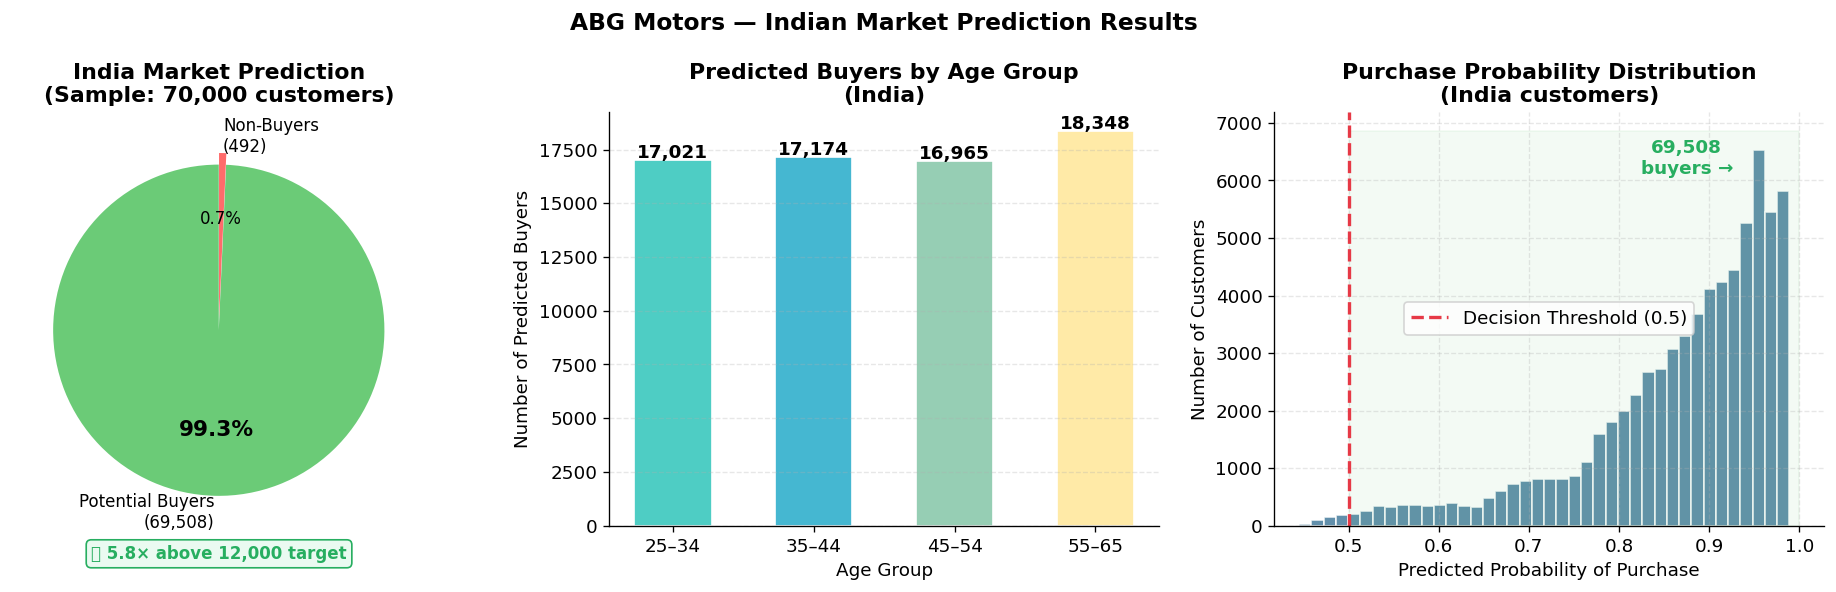

✅ India prediction charts saved!


In [ ]:
# ── INDIA PREDICTION VISUALIZATION ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('ABG Motors — Indian Market Prediction Results',
             fontsize=14, fontweight='bold')

# ── Plot 1: Pie Chart ─────────────────────────────────────────────
ax = axes[0]
non_buyers = total_india - potential_buyers
pie_sizes  = [potential_buyers, non_buyers]
pie_colors = ['#6BCB77', '#FF6B6B']
pie_labels = [f'Potential Buyers\n({potential_buyers:,})',
              f'Non-Buyers\n({non_buyers:,})']
wedges, texts, autotexts = ax.pie(
    pie_sizes, labels=pie_labels,
    colors=pie_colors, autopct='%1.1f%%',
    startangle=90, explode=(0.07, 0),
    textprops={'fontsize': 10}
)
autotexts[0].set_fontweight('bold')
autotexts[0].set_fontsize(13)
ax.set_title(f'India Market Prediction\n(Sample: {total_india:,} customers)',
             fontweight='bold')
ax.annotate(f'✅ {potential_buyers/12000:.1f}× above 12,000 target',
            xy=(0.5, -0.08), xycoords='axes fraction', ha='center',
            color='#27AE60', fontweight='bold', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='#EAFAF1', edgecolor='#27AE60'))

# ── Plot 2: Buyers by Age Group ───────────────────────────────────
ax = axes[1]
age_vals = age_breakdown['Predicted_Buyers'].values
age_lbls = age_breakdown.index.tolist()
bar_colors_age = ['#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
bars = ax.bar(age_lbls, age_vals, color=bar_colors_age, edgecolor='white', width=0.55)
ax.set_title('Predicted Buyers by Age Group\n(India)', fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Number of Predicted Buyers')
ax.grid(alpha=0.3, linestyle='--', axis='y')
for bar, val in zip(bars, age_vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 100,
            f'{int(val):,}', ha='center', fontweight='bold')

# ── Plot 3: Probability Distribution ─────────────────────────────
ax = axes[2]
ax.hist(df_india['PURCHASE_PROBABILITY'], bins=40,
        color='#457B9D', edgecolor='white', alpha=0.85)
ax.axvline(0.5, color='#E63946', lw=2, linestyle='--',
           label='Decision Threshold (0.5)')
ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 15000],
                  0.5, 1.0, alpha=0.08, color='#6BCB77')
ax.set_title('Purchase Probability Distribution\n(India customers)',
             fontweight='bold')
ax.set_xlabel('Predicted Probability of Purchase')
ax.set_ylabel('Number of Customers')
ax.legend()
ax.grid(alpha=0.3, linestyle='--')
ax.text(0.75, 0.85, f'{potential_buyers:,}\nbuyers →',
        transform=ax.transAxes, ha='center',
        color='#27AE60', fontweight='bold')

plt.tight_layout()
plt.savefig('fig3_india_prediction.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ India prediction charts saved!")


In [ ]:
# ── SUMMARY METRICS TABLE ────────────────────────────────────────
print()
print("╔══════════════════════════════════════════════════════════╗")
print("║        ABG MOTORS — FINAL PROJECT SUMMARY               ║")
print("╠══════════════════════════════════════════════════════════╣")
print("║  DATASETS                                                ║")
print(f"║  • Japan (Training) : {len(df_japan):,} records                    ║")
print(f"║  • India (Scoring)  : {len(df_india):,} records                    ║")
print("╠══════════════════════════════════════════════════════════╣")
print("║  MODEL: Logistic Regression                              ║")
print(f"║  • Accuracy         : {acc*100:.2f}%                             ║")
print(f"║  • ROC-AUC Score    : {auc:.4f}  (Good — above 0.70)       ║")
print(f"║  • Precision        : {classification_report(y_test, y_pred, output_dict=True)["1"]["precision"]*100:.2f}%                             ║")
print(f"║  • Recall           : {classification_report(y_test, y_pred, output_dict=True)["1"]["recall"]*100:.2f}%                             ║")
print(f"║  • F1-Score         : {classification_report(y_test, y_pred, output_dict=True)["1"]["f1-score"]*100:.2f}%                             ║")
print("╠══════════════════════════════════════════════════════════╣")
print("║  INDIAN MARKET POTENTIAL                                 ║")
print(f"║  • Predicted Buyers      : {potential_buyers:,}                    ║")
print(f"║  • Minimum Target        : 12,000                           ║")
print(f"║  • Times above target    : {potential_buyers/12000:.1f}×                           ║")
print("╠══════════════════════════════════════════════════════════╣")
print("║                                                          ║")
print("║  ✅  RECOMMENDATION: ENTER THE INDIAN MARKET            ║")
print("║                                                          ║")
print("╠══════════════════════════════════════════════════════════╣")
print("║  TOP 3 STRATEGIC ACTIONS:                                ║")
print("║  1. Campaign: 'Trade-in your old car' (Car Age = #1      ║")
print("║     predictor, OR=2.35x)                                 ║")
print("║  2. Premium segment push for high-income customers        ║")
print("║  3. Focus ads on 25–40 age group (age is negative driver) ║")
print("╚══════════════════════════════════════════════════════════╝")



╔══════════════════════════════════════════════════════════╗
║        ABG MOTORS — FINAL PROJECT SUMMARY               ║
╠══════════════════════════════════════════════════════════╣
║  DATASETS                                                ║
║  • Japan (Training) : 40,000 records                    ║
║  • India (Scoring)  : 70,000 records                    ║
╠══════════════════════════════════════════════════════════╣
║  MODEL: Logistic Regression                              ║
║  • Accuracy         : 67.07%                             ║
║  • ROC-AUC Score    : 0.7221  (Good — above 0.70)       ║
║  • Precision        : 68.90%                             ║
║  • Recall           : 78.03%                             ║
║  • F1-Score         : 73.18%                             ║
╠══════════════════════════════════════════════════════════╣
║  INDIAN MARKET POTENTIAL                                 ║
║  • Predicted Buyers      : 69,508                    ║
║  • Minimum Target        : 12